In [8]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix, 
                             ConfusionMatrixDisplay, classification_report, 
                             accuracy_score, f1_score)    
import json
from pathlib import Path                       

In [9]:
TRAIN_PATH_FULL = "../../../data/processed/full_train/train.csv"
TRAIN_PATH_SPLIT = "../../../data/processed/split_85_15/train_85.csv"
TEST_PATH_SPLIT  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_PATH="../../../output/svm_classifier/"
OUTPUT_PATH_BR="../../../output/bayesian_ridge/"

REGRESSOR_OUTPUT_PATH  = os.path.join(OUTPUT_PATH_BR, "pred_margin_test_bayesian.csv")
train_df = pd.read_csv(TRAIN_PATH_SPLIT)
test_df_real = pd.read_csv(TEST_PATH_SPLIT)
test_df_predict = pd.read_csv(REGRESSOR_OUTPUT_PATH)

TARGET_COL = "faulty"

FEATURES_REAL = ["trq_margin", "oat", "pa", "np_ng_ratio", "ias", "mgt"]
FEATURES_PRED = ["trq_margin_pred", "oat", "pa", "np_ng_ratio", "ias", "mgt"]

In [10]:
X_train = train_df[FEATURES_REAL].values
y_train = train_df[TARGET_COL].values

X_test_real = test_df_real[FEATURES_REAL].values
y_test_real = test_df_real[TARGET_COL].values

X_test_predict = test_df_predict[FEATURES_PRED].values
y_test_predict = test_df_predict[TARGET_COL].values

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_real_scaled = scaler.transform(X_test_real)
X_test_predict_scaled = scaler.transform(X_test_predict)

svm_model = SGDClassifier(loss="hinge", penalty="l2", random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [12]:
def challenge_score(true_label, pred_label, confidence):

    if (confidence < 0) or (confidence > 1):
        return -100

    if pred_label not in [0, 1]:
        return -100

    if pred_label != true_label:
        confidence = -confidence

    if true_label == 0:
        return confidence
    
    else:
        if confidence >= 0:
            return confidence
        else:
            return 4 * confidence ** 11 + 1.0 * confidence


 RISULTATI SENZA SOGLIA OTTIMIZZATA SU: TEST 15% (MARGINE REALE)
Accuracy:        0.9345
F1 Score:        0.9175
Total PHM Score: 85637.65
Mean Score:      0.7688


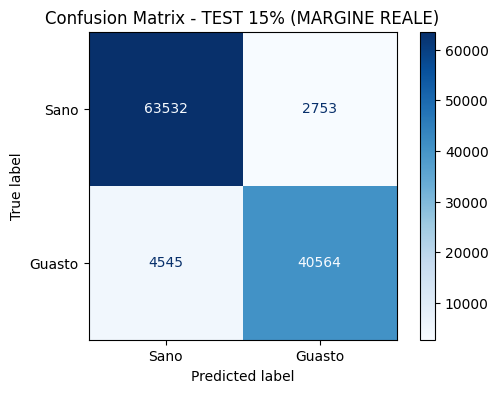


 RISULTATI SENZA SOGLIA OTTIMIZZATA SU: TEST 15% (MARGINE PREDETTO)
Accuracy:        0.9342
F1 Score:        0.9171
Total PHM Score: 85573.31
Mean Score:      0.7682


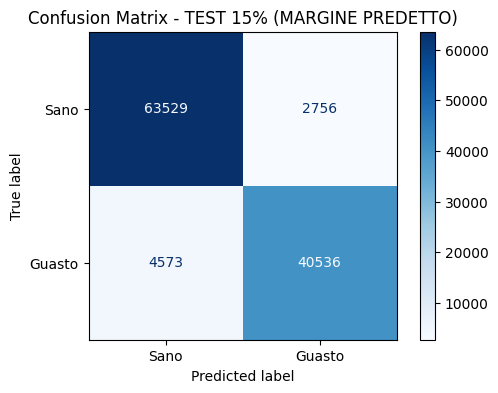

In [13]:
def evaluate_model(X_eval, y_eval, name):
    y_pred = svm_model.predict(X_eval)
    
    # Calcolo della confidenza tramite distanza dall'iperpiano (decision_function)
    # Trasformata in range [0, 1] tramite sigmoide
    decision_scores = svm_model.decision_function(X_eval)
    confidences = 1 / (1 + np.exp(-np.abs(decision_scores)))
    
    scores = [challenge_score(t, p, c) for t, p, c in zip(y_eval, y_pred, confidences)]
    
    print(f"\n" + "="*50)
    print(f" RISULTATI SENZA SOGLIA OTTIMIZZATA SU: {name}")
    print("="*50)
    print(f"Accuracy:        {accuracy_score(y_eval, y_pred):.4f}")
    print(f"F1 Score:        {f1_score(y_eval, y_pred):.4f}")
    print(f"Total PHM Score: {np.sum(scores):.2f}")
    print(f"Mean Score:      {np.mean(scores):.4f}")
    
    
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_eval, y_pred, 
                                            display_labels=["Sano", "Guasto"], 
                                            cmap="Blues", ax=ax, values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

# FASE DI TEST 
# Test 1: su dati reali (test_15.csv)
evaluate_model(X_test_real_scaled, y_test_real, "TEST 15% (MARGINE REALE)")

# Test 2: Su output del regressore (pred_margin_test_bayesian.csv)
evaluate_model(X_test_predict_scaled, y_test_predict, "TEST 15% (MARGINE PREDETTO)")

In [ ]:
OUTPUT_PATH_BR = "../../../output/bayesian_ridge/"
OUTPUT_PATH_SVM = "../../../output/svm_classifier/"

# JSON parziale dal Bayesian Ridge
partial_json_path = Path(OUTPUT_PATH_BR) / "submission_regression_br.json"
with open(partial_json_path, "r") as f:
    submission = json.load(f)

print(f"JSON parziale caricato: {len(submission)} campioni")

# --- Predizioni classificazione ---
class_preds  = svm_model.predict(X_test_predict_scaled)
decision_scores = svm_model.decision_function(X_test_predict_scaled)
class_confs = 1 / (1 + np.exp(-np.abs(decision_scores)))  

for i in range(len(class_preds)):
    submission[str(i)]["class"] = int(class_preds[i])
    submission[str(i)]["class_conf"] = round(float(class_confs[i]), 6)

final_json_path = Path(OUTPUT_PATH_SVM) / "submission_svm.json"
final_json_path.parent.mkdir(parents=True, exist_ok=True)  

with open(final_json_path, "w") as f:
    json.dump(submission, f, indent=4)

print(f"Submission finale salvata in: {final_json_path}")

for k in list(submission.keys())[:3]:
    print(f"{k}: {submission[k]}")


JSON parziale caricato: 111394 campioni
Submission finale salvata in: ..\..\..\output\svm_classifier\submission_svm.json
0: {'pdf_type': 'normal', 'pdf_args': {'mu': 74.98496192114861, 'sigma': 0.03628947086872789}, 'class': 1, 'class_conf': 0.717936}
1: {'pdf_type': 'normal', 'pdf_args': {'mu': 76.68254554462293, 'sigma': 0.036289766332323566}, 'class': 1, 'class_conf': 0.852999}
2: {'pdf_type': 'normal', 'pdf_args': {'mu': 76.9215055928876, 'sigma': 0.03629087277363801}, 'class': 1, 'class_conf': 0.745307}
